# Grover's Algorithm

Grover's algorithm is the most famous "quadratic speed-up" in quantum computing:

> **Problem.** A black-box function `f : {0,…,N-1} → {0,1}` is `1` for exactly one input – the *winner* – and `0` elsewhere. Find the winner.
>
> **Classical cost:** `O(N)` queries.
> **Quantum cost:** `O(√N)` queries.

For our toy 2-qubit example the search space is just 4 states and a single Grover iteration finds the answer with probability `1`.

> **What changed since the original notebook?** The standard Qiskit-1.0 / 2.x updates (explicit imports, `qiskit_aer.AerSimulator`, `transpile` + `run`). We also call `oracleCircuit.to_gate()` *at the moment of appending* – simply assigning `oracleCircuit.to_gate()` to nothing didn't actually use the result.

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

%matplotlib inline

## Classical baseline

A classical computer has to look at the items one by one. On average it takes `N/2` queries (and in the worst case `N` queries) to find the winner.

In [2]:
# --- Classical search (the baseline we want to beat) ---

In [3]:
myList = [5,4,6,9,1,2,3,7,8,0]

In [4]:
def oracle(number):
    winningNumber = 8
    if number == winningNumber:
        response = True
    else:
        response = False
    return response

In [5]:
for index, number in enumerate(myList):
    if oracle(number) is True:
        print(f"winning number index: {index}")
        print(f"execution count: {index + 1}")
        break

winning number index: 8
execution count: 9


## Grover's algorithm – the quantum way

For a 2-qubit search space (4 states) we'll mark `|11⟩` as the "winning state". Grover's algorithm has two ingredients we'll build separately:

1. **An oracle** that flips the phase of the winning state.
2. **A diffuser** (the "reflection about the mean") that amplifies whichever state has a different phase.

For a 2-qubit problem with one marked item, Grover's algorithm finds it in **a single iteration with 100% probability** – beating the *average* `2.5` queries that classical search needs.

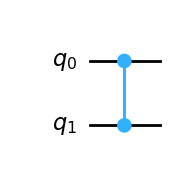

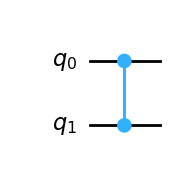

In [6]:
# --- Quantum search: Grover's algorithm ---
# Oracle circuit – marks the winning state |11⟩ by flipping its phase.

oracleCircuit = QuantumCircuit(2, name="oracleCircuit")
oracleCircuit.cz(0, 1)  # phase-flips |11⟩, leaves the rest alone
oracleCircuit.draw(output='mpl')

### Step 1 – uniform superposition + oracle

We put both qubits into superposition (so we are "asking the oracle about all four states at once"), then apply the oracle as a sub-routine. The oracle marks the winner with a minus sign – an *invisible* change as far as a measurement is concerned, but a real change in the wavefunction.

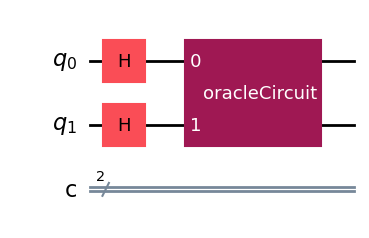

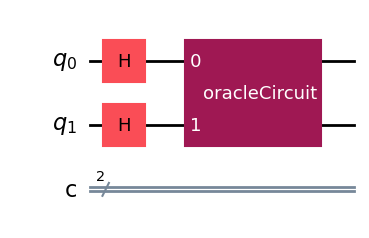

In [7]:
mainCircuit = QuantumCircuit(2, 2)
mainCircuit.h([0, 1])
# Convert the oracle circuit into a re-usable gate and plug it in.
mainCircuit.append(oracleCircuit.to_gate(), [0, 1])
mainCircuit.draw(output='mpl')

### The diffuser (a.k.a. "reflection about the mean")

After the oracle has put a tiny minus sign on the winning state, the diffuser amplifies that tiny sign into a big amplitude. Geometrically it is a reflection about the uniform superposition vector. For 2 qubits one round of `H–Z–CZ–H` does the job.

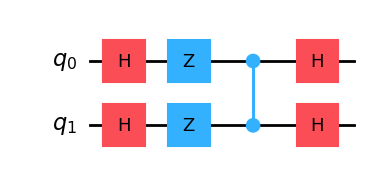

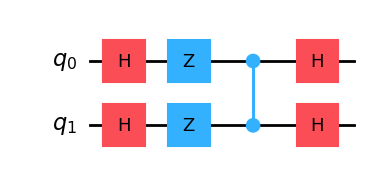

In [8]:
reflectionCircuit = QuantumCircuit(2, name="reflectionCircuit")
reflectionCircuit.h([0, 1])
reflectionCircuit.z([0, 1])
reflectionCircuit.cz(0, 1)
reflectionCircuit.h([0, 1])
reflectionCircuit.draw(output='mpl')

### Putting the iteration together and measuring

We append the diffuser to the main circuit and measure both qubits.

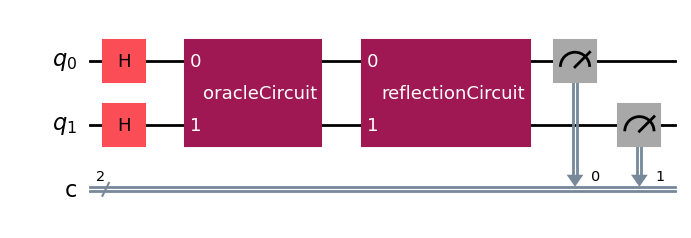

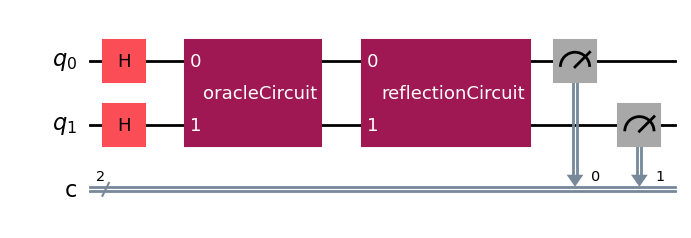

In [9]:
mainCircuit.append(reflectionCircuit.to_gate(), [0, 1])
mainCircuit.measure([0, 1], [0, 1])
mainCircuit.draw(output='mpl')

### Running it

For a 2-qubit search with one marked item, **a single Grover iteration solves it deterministically** – every shot returns `11`. We use 1 shot to drive the point home.

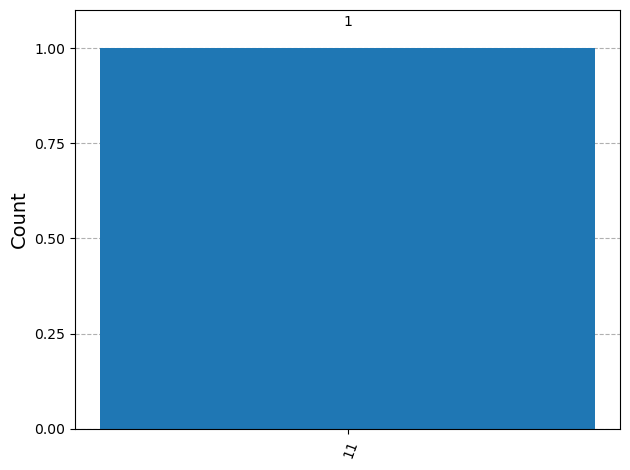

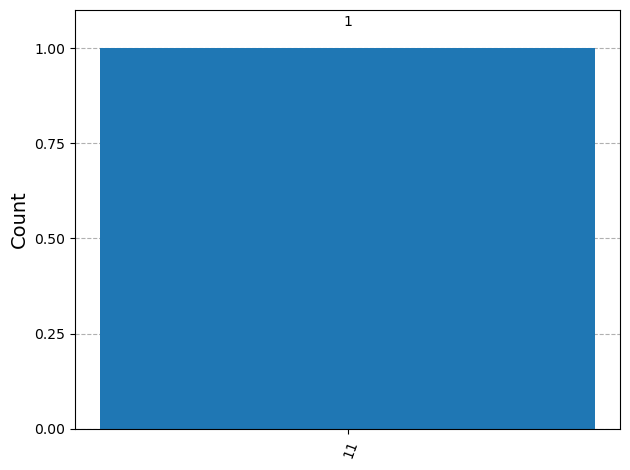

In [10]:
simulator = AerSimulator()
compiled = transpile(mainCircuit, simulator)
result = simulator.run(compiled, shots=1).result()
counts = result.get_counts(mainCircuit)
plot_histogram([counts])